# Phylogenetic analysis of the Indian big four snakes using COX1

# Introduction
The "Big four" venomous snakes of India - Naja naja(Indian cobra), Bungarus caeruleus(common krait), Daboia russelii(Russell's viper), Ophiophagus hannah(king cobra) are responsible for majority of snakebite cases in India. This project uses the mitochondrial COX1 gene to examine the genetic relationships between these four species and reconstruct their evolutionary relationships using a phylogenetic tree.

COX1 was chosen as it is universally present across animals, mutates at a moderate rate and being protein coding resists insertions/deletions that would otherwise complicate alignment.

# Data Collection
The four COX1 sequences were obtained from NCBI by manually verifying each accession to confirm correct species, gene identity(COX1, not a full mitochondiral gene), and adequate sequence length.
- Naja naja: PP716451.1 (681 bp)
- Bungarus caeruleus: OR186190.1 (704 bp)
- Daboia russelii: MT215094.1 (704 bp)
- Ophiophagus hannah: MW021413.1 (627 bp)

Species identity was independently confirmed via programmatic BLAST search against NCBI's nucleotide database prior to this analysis.

In [1]:
from Bio import SeqIO
aligned_sequences = list(SeqIO.parse('aligned_snakes.fasta', 'fasta'))
for record in aligned_sequences:
    print(record.id , len(record.seq))
    

PP716451.1 730
OR186190.1 730
MT215094.1 730
MW021413.1 730


## COX1 sequence of Four Indian snakes
-COX1 was selected as it is the standard DNA barcoding marker, due to its universal presence, moderate mutation rate and resistance to indels.

-After alignment, all four sequences now show 730 real characters(bases plus inserted gaps) confirming the same length, so every position is directly comparable across all species.

In [2]:
for record1 in aligned_sequences:
    for record2 in aligned_sequences:
        if record1.id != record2.id:
            seq1 = str(record1.seq)
            seq2 = str(record2.seq)
            count = 0
            for i in range(len(seq1)):
                if seq1[i] != seq2[i]:
                    count += 1
            print(record1.id, record2.id, count)        

PP716451.1 OR186190.1 143
PP716451.1 MT215094.1 213
PP716451.1 MW021413.1 149
OR186190.1 PP716451.1 143
OR186190.1 MT215094.1 185
OR186190.1 MW021413.1 179
MT215094.1 PP716451.1 213
MT215094.1 OR186190.1 185
MT215094.1 MW021413.1 189
MW021413.1 PP716451.1 149
MW021413.1 OR186190.1 179
MW021413.1 MT215094.1 189


-Naja-Ophiophagus distance may be inflated relative to true evolutionary divergence due to Ophiophagus's shorter sequenced fragment introducing additional gap positions.

In [2]:
from Bio.Phylo.TreeConstruction import DistanceMatrix
names = [record.id for record in aligned_sequences]
sequences_str = [str(record.seq) for record in aligned_sequences]

matrix_data = []
for i in range(len(sequences_str)):
    row = []
    for j in range(i + 1):
        if i == j:
            row.append(0)
        else:
            count = 0
            for k in range(len(sequences_str[i])):
                if sequences_str[i][k] != sequences_str[j][k]:
                    count += 1
            row.append(count)
    matrix_data.append(row)

distance_matrix = DistanceMatrix(names, matrix_data)
print(distance_matrix)

                

PP716451.1  0.000000
OR186190.1  143.000000  0.000000
MT215094.1  213.000000  185.000000  0.000000
MW021413.1  149.000000  179.000000  189.000000  0.000000
    PP716451.1  OR186190.1  MT215094.1  MW021413.1


In [3]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
constructor = DistanceTreeConstructor()
tree = constructor.upgma(distance_matrix)
print(tree)

Tree(rooted=True)
    Clade(branch_length=0, name='Inner3')
        Clade(branch_length=97.0, name='MT215094.1')
        Clade(branch_length=15.0, name='Inner2')
            Clade(branch_length=82.0, name='MW021413.1')
            Clade(branch_length=10.5, name='Inner1')
                Clade(branch_length=71.5, name='OR186190.1')
                Clade(branch_length=71.5, name='PP716451.1')


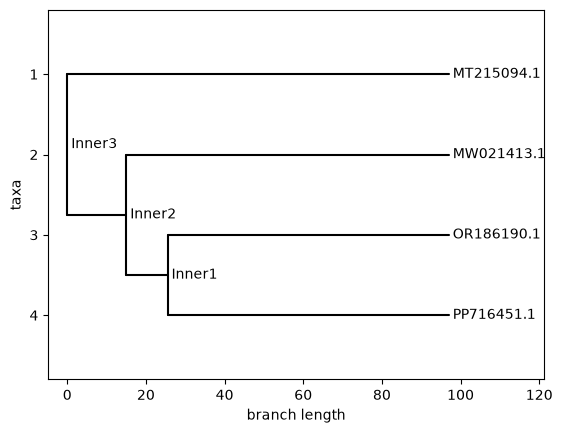

In [4]:
from Bio import Phylo
import matplotlib.pyplot as plt
Phylo.draw(tree)

# Discussion and Conclusion

The UPGMA tree constructed from COX1 pairwise distances groups Naja naja snd Bungarus caeruleus as the closest pair, with Ophiophagus hannah joining the cluster next, and Daboia russelii branching off separately as the most distant species. This is consistent with established snake taxonomy: Naja, Bungarus and Ophiophagus all belong to the family Elapidae, while Daboia belongs to the distict family Viperidae.

One limitation worth noting: Ophiophagus hannah's sequenced fragment (627 bp) was shorter than the others (681-704bp), introducing additional end-gaps during alignment. Since gap positions were counted identically to base mismatches in this analysis, Ophiophagus's distances to other species may be inflated relative to their true evolutionary divergence. This did not appear to affect the overall tree topology(grouping), but it is a caveat worth keeping in mind when interpreting exact branch lengths.

# Possible future extensions
- Use a distance metric that accounts for gaps separately from mismatches(e.g., ignoring gap positions entirely)
- Include additional Indian snake species or a wider outgroup.